<a href="https://www.kaggle.com/code/lalit7881/used-car-price-prediction-eda?scriptVersionId=326865172" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muhammadmusharraf444/used-car-price-prediction-dataset/quikr_car.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/muhammadmusharraf444/used-car-price-prediction-dataset/quikr_car.csv")

In [3]:
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [4]:
df.tail()

,name,company,year,Price,kms_driven,fuel_type
887,Ta,Tara,zest,"3,10,000",NaN,NaN
888,Tata Zest XM Diesel,Tata,2018,"2,60,000","27,000 kms",Diesel
889,Mahindra Quanto C8,Mahindra,2013,"3,90,000","40,000 kms",Diesel
890,Honda Amaze 1.2 E i VTEC,Honda,2014,"1,80,000",Petrol,NaN
891,Chevrolet Sail 1.2 LT ABS,Chevrolet,2014,"1,60,000",Petrol,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [6]:
df.describe()

,name,company,year,Price,kms_driven,fuel_type
count,892,892,892,892,840,837
unique,525,48,61,274,258,3
top,Honda City,Maruti,2015,Ask For Price,"45,000 kms",Petrol
freq,13,235,117,35,30,440


In [7]:
df.isnull()

,name,company,year,Price,kms_driven,fuel_type
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
887,False,False,False,False,True,True
888,False,False,False,False,False,False
889,False,False,False,False,False,False
890,False,False,False,False,False,True


In [8]:
df.isnull().sum()

name           0
company        0
year           0
Price          0
kms_driven    52
fuel_type     55
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(94)

In [10]:
df.shape

(892, 6)

In [11]:
df.dtypes

name          object
company       object
year          object
Price         object
kms_driven    object
fuel_type     object
dtype: object

In [12]:
df.columns

Index(['name', 'company', 'year', 'Price', 'kms_driven', 'fuel_type'], dtype='object')

In [13]:
df.nunique

<bound method DataFrame.nunique of                                        name    company  year          Price  \
0      Hyundai Santro Xing XO eRLX Euro III    Hyundai  2007         80,000   
1                   Mahindra Jeep CL550 MDI   Mahindra  2006       4,25,000   
2                Maruti Suzuki Alto 800 Vxi     Maruti  2018  Ask For Price   
3    Hyundai Grand i10 Magna 1.2 Kappa VTVT    Hyundai  2014       3,25,000   
4          Ford EcoSport Titanium 1.5L TDCi       Ford  2014       5,75,000   
..                                      ...        ...   ...            ...   
887                                      Ta       Tara  zest       3,10,000   
888                     Tata Zest XM Diesel       Tata  2018       2,60,000   
889                      Mahindra Quanto C8   Mahindra  2013       3,90,000   
890                Honda Amaze 1.2 E i VTEC      Honda  2014       1,80,000   
891               Chevrolet Sail 1.2 LT ABS  Chevrolet  2014       1,60,000   

     kms_driven 

## EDA

In [14]:
import numpy as np

def clean_kms(x):
    x = str(x).lower().strip()

    x = x.replace(',', '')
    x = x.replace('kms', '')
    x = x.replace('km', '')
    x = x.strip()

    if 'k' in x:
        try:
            return float(x.replace('k', '')) * 1000
        except:
            return np.nan

    try:
        return float(x)
    except:
        return np.nan

df['kms_driven'] = df['kms_driven'].apply(clean_kms)

print(df['kms_driven'].dtype)
print(df['kms_driven'].head())

float64
0    45000.0
1       40.0
2    22000.0
3    28000.0
4    36000.0
Name: kms_driven, dtype: float64


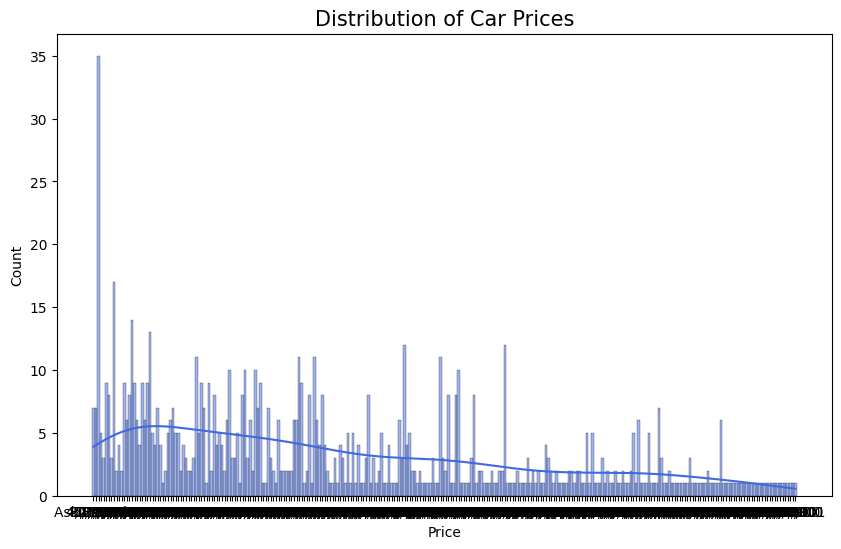

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df['Price'], bins=30, color='royalblue', kde=True)

plt.title('Distribution of Car Prices', fontsize=15)
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

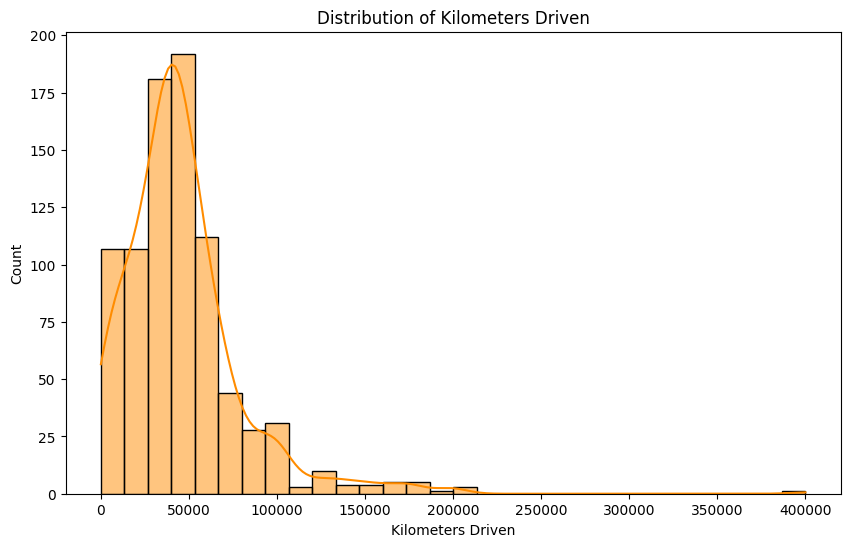

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(df['kms_driven'],
             bins=30,
             color='darkorange',
             kde=True)

plt.title('Distribution of Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Count')
plt.show()

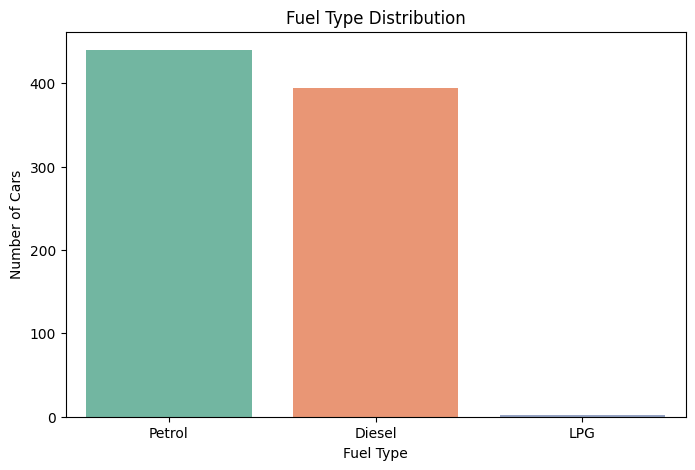

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='fuel_type',
    data=df,
    palette='Set2'
)

plt.title('Fuel Type Distribution')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')
plt.show()

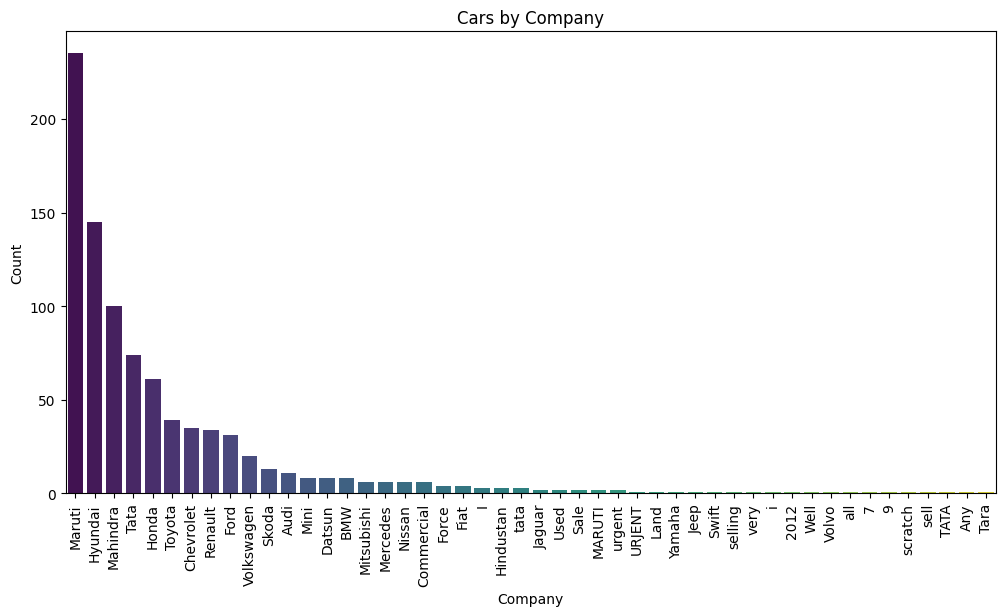

In [18]:
plt.figure(figsize=(12,6))

company_count = df['company'].value_counts()

sns.barplot(
    x=company_count.index,
    y=company_count.values,
    palette='viridis'
)

plt.xticks(rotation=90)
plt.title('Cars by Company')
plt.xlabel('Company')
plt.ylabel('Count')
plt.show()

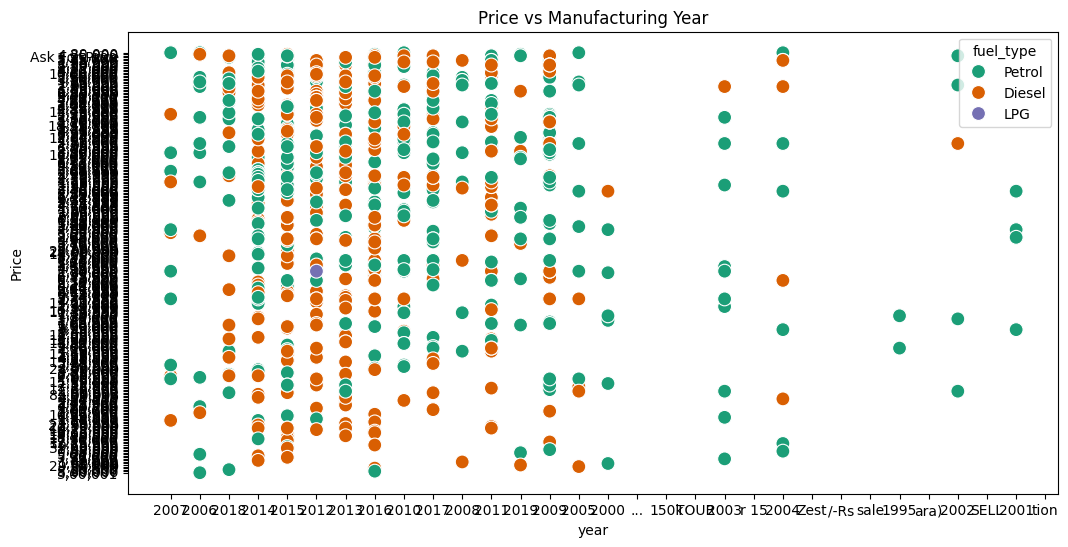

In [19]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x='year',
    y='Price',
    data=df,
    hue='fuel_type',
    palette='Dark2',
    s=100
)

plt.title('Price vs Manufacturing Year')
plt.show()

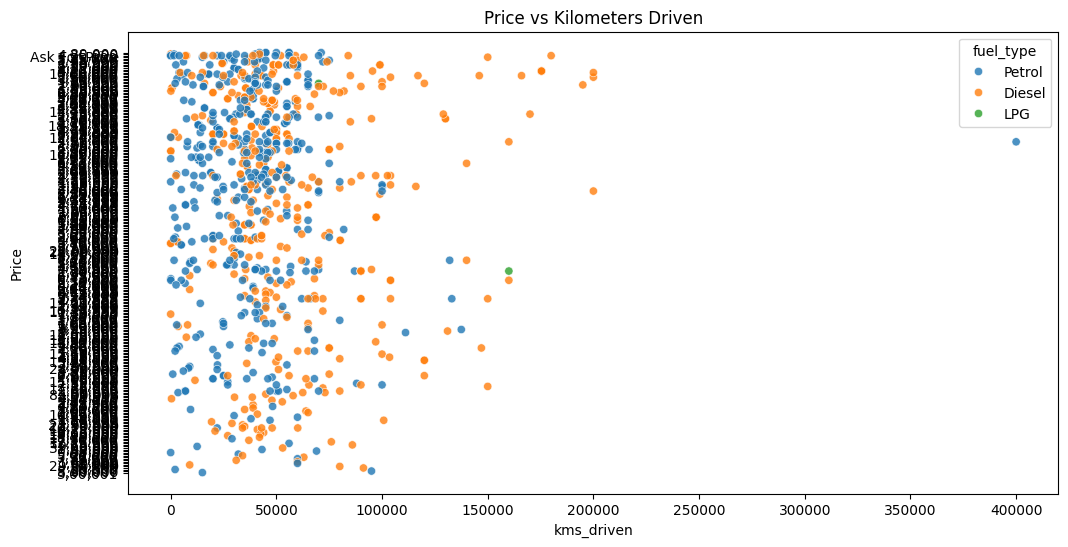

In [20]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x='kms_driven',
    y='Price',
    data=df,
    hue='fuel_type',
    palette='tab10',
    alpha=0.8
)

plt.title('Price vs Kilometers Driven')
plt.show()

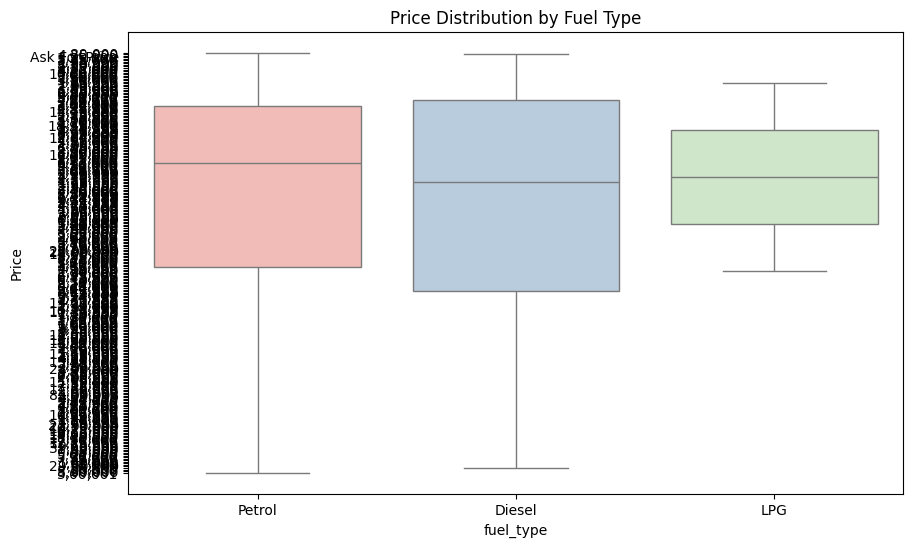

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='fuel_type',
    y='Price',
    data=df,
    palette='Pastel1'
)

plt.title('Price Distribution by Fuel Type')
plt.show()

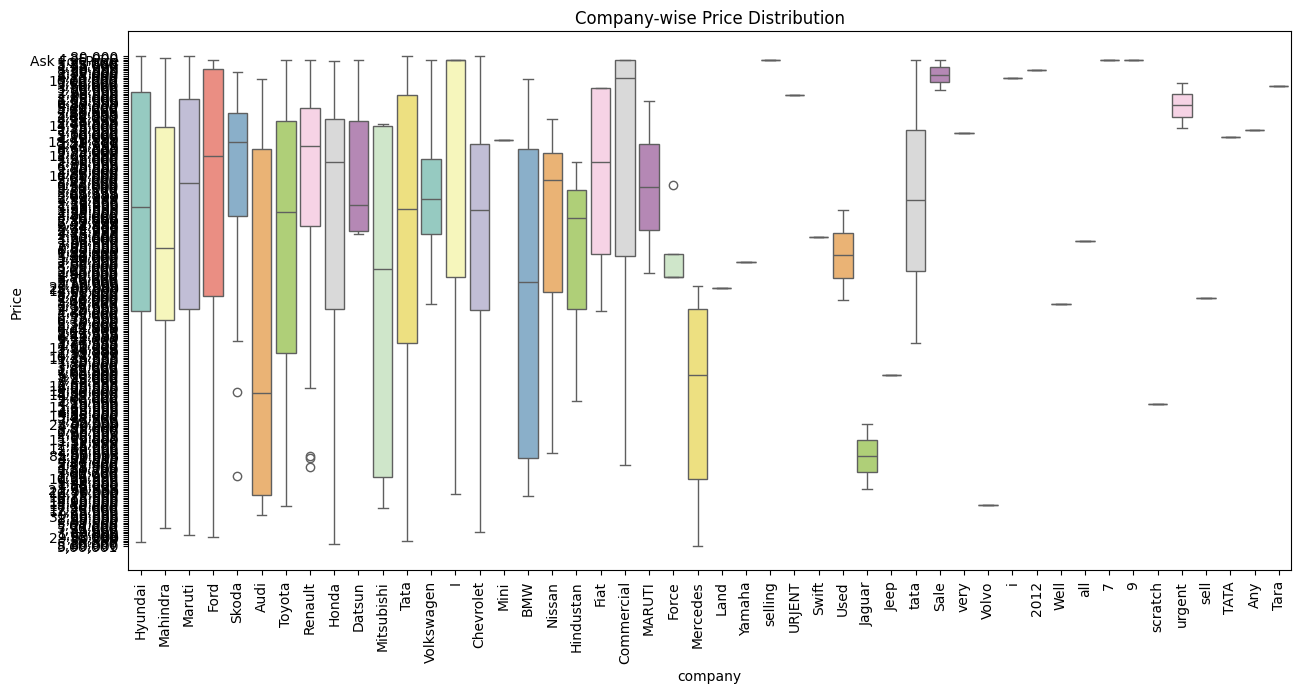

In [22]:
plt.figure(figsize=(15,7))

sns.boxplot(
    x='company',
    y='Price',
    data=df,
    palette='Set3'
)

plt.xticks(rotation=90)
plt.title('Company-wise Price Distribution')
plt.show()

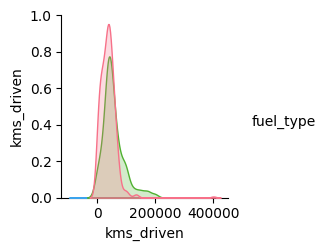

In [23]:
sns.pairplot(
    df[['year','Price','kms_driven','fuel_type']],
    hue='fuel_type',
    palette='husl'
)

plt.show()

In [24]:
# Force conversion
df['Price'] = df['Price'].astype(str)

df['Price'] = df['Price'].str.replace(',', '', regex=False)
df['Price'] = df['Price'].str.replace('₹', '', regex=False)
df['Price'] = df['Price'].str.strip()

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

print(df['Price'].dtype)

float64


In [25]:
print(df[['Price']].head())

      Price
0   80000.0
1  425000.0
2       NaN
3  325000.0
4  575000.0


In [26]:
df.groupby('company')['Price'].mean()

company
2012          2.500000e+05
7                      NaN
9                      NaN
Any           1.700000e+05
Audi          1.476909e+06
BMW           1.049875e+06
Chevrolet     2.008828e+05
Commercial    2.588333e+05
Datsun        2.557140e+05
Fiat          1.098750e+05
Force         5.725000e+05
Ford          4.797999e+05
Hindustan     3.033333e+05
Honda         3.448848e+05
Hyundai       3.184028e+05
I             4.750000e+05
Jaguar        2.495000e+06
Jeep          9.500000e+05
Land          2.100000e+06
MARUTI        5.250000e+05
Mahindra      6.008767e+05
Maruti        2.708330e+05
Mercedes      1.170667e+06
Mini          1.891111e+06
Mitsubishi    1.298333e+06
Nissan        4.606663e+05
Renault       4.605123e+05
Sale          1.000000e+05
Skoda         2.511914e+05
Swift         3.700000e+05
TATA          1.100000e+05
Tara          3.100000e+05
Tata          2.031579e+05
Toyota        5.177025e+05
URJENT        1.800000e+05
Used          2.025000e+05
Volkswagen    4.0710

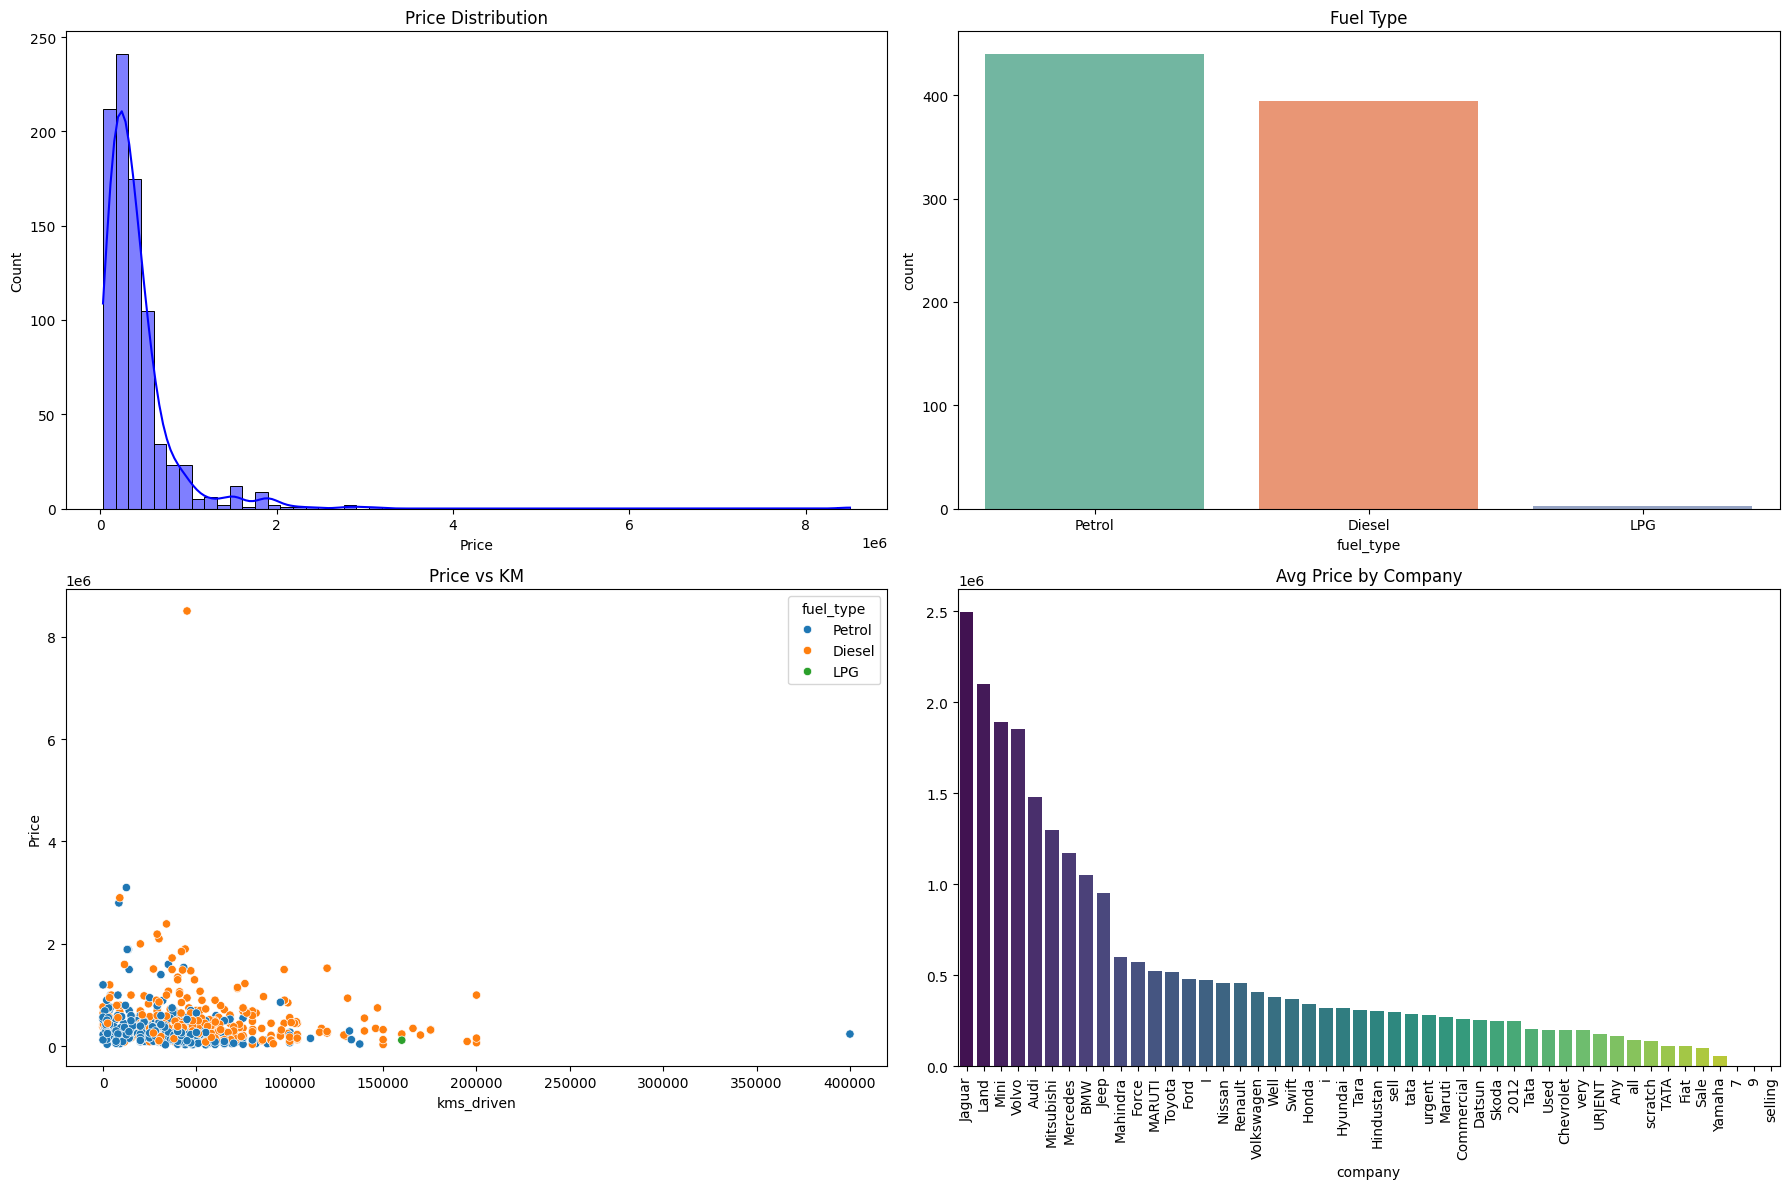

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Price Distribution
sns.histplot(df['Price'],
             kde=True,
             color='blue',
             ax=axes[0,0])
axes[0,0].set_title('Price Distribution')

# Fuel Type Count
sns.countplot(
    x='fuel_type',
    data=df,
    palette='Set2',
    ax=axes[0,1]
)
axes[0,1].set_title('Fuel Type')

# Price vs KM
sns.scatterplot(
    x='kms_driven',
    y='Price',
    data=df,
    hue='fuel_type',
    palette='tab10',
    ax=axes[1,0]
)
axes[1,0].set_title('Price vs KM')

# Average Price by Company
avg_price = df.groupby('company')['Price'].mean().sort_values(ascending=False)

sns.barplot(
    x=avg_price.index,
    y=avg_price.values,
    palette='viridis',
    ax=axes[1,1]
)

axes[1,1].tick_params(axis='x', rotation=90)
axes[1,1].set_title('Avg Price by Company')

plt.tight_layout()
plt.show()

## Feature engineering

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

In [29]:
# Remove missing values
df = df.copy()

# Clean Price
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Clean kms_driven
df['kms_driven'] = pd.to_numeric(df['kms_driven'], errors='coerce')

# Clean year
df['year'] = pd.to_numeric(df['year'], errors='coerce')

df = df.dropna()

In [30]:
median_price = df['Price'].median()

df['target'] = np.where(
    df['Price'] > median_price,
    1,
    0
)

print(df['target'].value_counts())

target
0    409
1    407
Name: count, dtype: int64


In [31]:
X = df[['name',
        'company',
        'year',
        'kms_driven',
        'fuel_type']]

y = df['target']

In [32]:
categorical_cols = [
    'name',
    'company',
    'fuel_type'
]

encoders = {}

for col in categorical_cols:
    
    le = LabelEncoder()
    
    X[col] = le.fit_transform(
        X[col].astype(str)
    )
    
    encoders[col] = le

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (652, 5)
Test Shape: (164, 5)


In [34]:
lr = LogisticRegression(
    max_iter=5000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print("Logistic Accuracy:", lr_acc)

print(
    classification_report(
        y_test,
        lr_pred
    )
)

Logistic Accuracy: 0.7317073170731707
              precision    recall  f1-score   support

           0       0.76      0.67      0.71        82
           1       0.71      0.79      0.75        82

    accuracy                           0.73       164
   macro avg       0.74      0.73      0.73       164
weighted avg       0.74      0.73      0.73       164



In [35]:
dt = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(X_test)

dt_prob = dt.predict_proba(X_test)[:,1]

dt_acc = accuracy_score(
    y_test,
    dt_pred
)

print("Decision Tree Accuracy:", dt_acc)

print(
    classification_report(
        y_test,
        dt_pred
    )
)

Decision Tree Accuracy: 0.8475609756097561
              precision    recall  f1-score   support

           0       0.89      0.79      0.84        82
           1       0.81      0.90      0.86        82

    accuracy                           0.85       164
   macro avg       0.85      0.85      0.85       164
weighted avg       0.85      0.85      0.85       164



In [36]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_acc)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Random Forest Accuracy: 0.8841463414634146
              precision    recall  f1-score   support

           0       0.87      0.90      0.89        82
           1       0.90      0.87      0.88        82

    accuracy                           0.88       164
   macro avg       0.88      0.88      0.88       164
weighted avg       0.88      0.88      0.88       164



In [37]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy':[
        lr_acc,
        dt_acc,
        rf_acc
    ]
})

print(results)

results.sort_values(
    by='Accuracy',
    ascending=False
)

                 Model  Accuracy
0  Logistic Regression  0.731707
1        Decision Tree  0.847561
2        Random Forest  0.884146


,Model,Accuracy
2,Random Forest,0.884146
1,Decision Tree,0.847561
0,Logistic Regression,0.731707


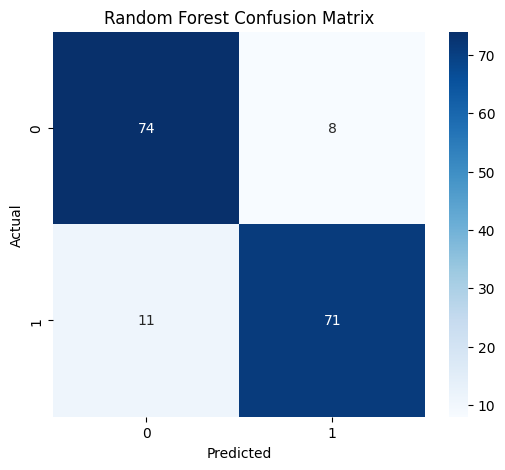

In [38]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(
        y_test,
        rf_pred
    ),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Random Forest Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [39]:
lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_prob
)

dt_fpr, dt_tpr, _ = roc_curve(
    y_test,
    dt_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

In [40]:
lr_auc = roc_auc_score(
    y_test,
    lr_prob
)

dt_auc = roc_auc_score(
    y_test,
    dt_prob
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("LR AUC :", lr_auc)
print("DT AUC :", dt_auc)
print("RF AUC :", rf_auc)

LR AUC : 0.7958060678167758
DT AUC : 0.88459250446163
RF AUC : 0.9501041046995836


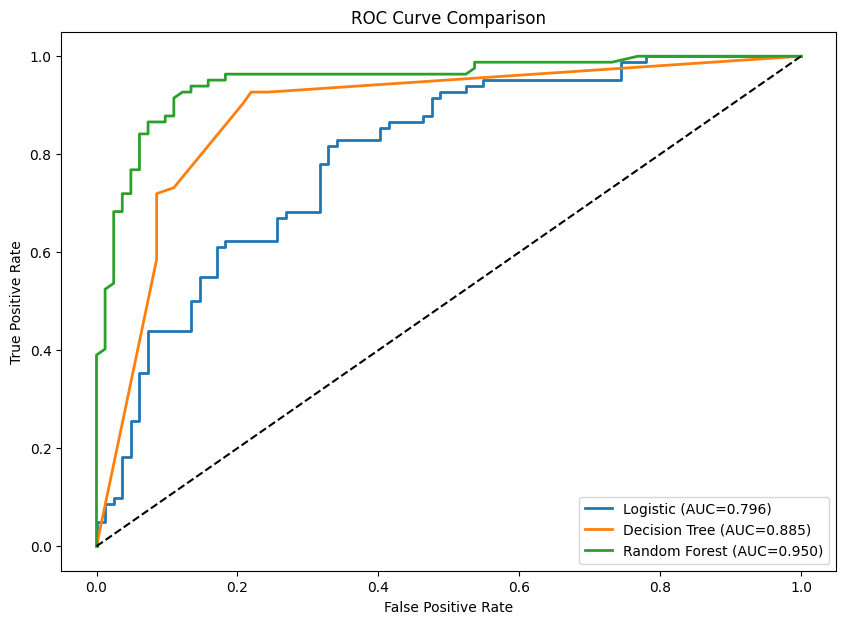

In [41]:
plt.figure(figsize=(10,7))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f'Logistic (AUC={lr_auc:.3f})',
    linewidth=2
)

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f'Decision Tree (AUC={dt_auc:.3f})',
    linewidth=2
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest (AUC={rf_auc:.3f})',
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

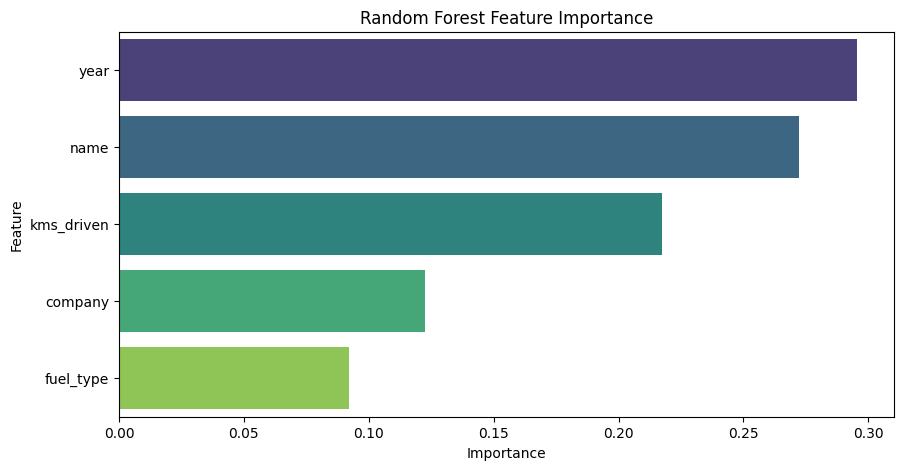

In [42]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title(
    'Random Forest Feature Importance'
)

plt.show()

## Thank you...pls upvote!!!!!!!!!!!!!!!1